## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Marilyn Ross

**Date:** 10/2/2026

1. Regression predicts a continuous numeric value but lassification predicts a discrete category label.
2. A confusion table is a table that shows how well a classification model is doing. It compares what the model predicted with what the actual labels were. The table has four parts: Positives, True Negatives, False Positives and False Negatives. These four categories help us see where the model is going wrong. True Positives mean the model correctly predicted a case. True Negatives mean it correctly said something was not positive. False Positives happen when the model says something is positive. It really isn't. False Negatives happen when the model says something is not positive. It actually is. This kind of table gives detail than just a simple accuracy number. It shows if the model is too focused on one class or if it makes mistakes that matter more than others. For example missing a disease (a False Negative) might be much worse, than saying someone has a disease (a False Positive). The confusion matrix helps us see these differences clearly.
3. The SSE measures the variation in the data that the regression model does not explain. It calculates the sum of the squared differences between the values and the values the model predicts. A smaller SSE means the models predictions are more accurate and closer, to the data points. Squaring the errors makes sure that bigger mistakes those caused by outliers are given more weight
4. Overfitting happens when a model is too complicated and learns the training data well. It starts to remember the noise and small changes in the data instead of learning the real pattern that exists. Underfitting happens when a model is too simple to find the patterns in the data. A model that is underfit doesn't do a job on the data it was trained on.
5. K decides how much a model remembers from its training data. If you let the training data itself decide where to set this dial, the model will push it all the way up to memory. It will get every practice question right. It will fail completely on any new data it hasn’t seen before. The key is to try values of k using a testing set that the model has never encountered. This prevents overfitting. It makes sure you pick the possible value of k, one that reflects the real patterns in the data. Then can your model perform well in actual situations, outside the training environment.
6. Class labels give easy to use decisions but don't show how certain the model really is. Probability distributions on the hand expose that uncertainty. This lets developers pick their risk levels based on what they need, turning those probabilities into a final decision takes more work and extra logic.

Q1
summary:
           voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000

distribution:
 mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
Q2
Q3
best k = 2, validation accuracy = 0.467


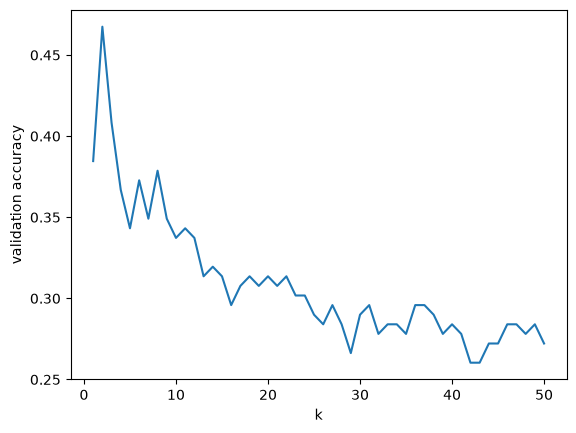

what i did? I Scanned k = 1 to 50, score each on the validation set, pick the k with highest validation accuracy
Q4
Predicted   1   2   3   4  5
Actual                      
1          27   0   5   2  2
2           0  31   2   1  1
3          10   2  10  10  1
4          15   6   3   9  0
5          15   0  10   5  2
accuracy: 0.467
accuracy is not great
So rows are actual, columns are  predicted, and diagonal is correct. Look for classes the model never predicts
Q5
Because the model still makes a lot of mistakes, I would advise against using it as an autonomous decision maker. Instead, it should be configured to output probability distributions rather than hard labels. This allows operators to flag predictions with low confidence or high uncertainty


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler
import numpy as np
print('Q1')
df = pd.read_csv('data/land_mines.csv')
print("summary:\n", df[['voltage', 'height', 'soil']].describe())
print("\ndistribution:\n", df['mine_type'].value_counts())

print('Q2')
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X, y, test_size=0.50, stratify=y, random_state=65
)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_valid = scaler.transform(X_valid_raw)

print('Q3')
ks = np.arange(1, 51)
valid_acc = []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=int(k)).fit(X_train, y_train)
    valid_acc.append(accuracy_score(y_valid, m.predict(X_valid)))

k_star = int(ks[np.argmax(valid_acc)])
print(f"best k = {k_star}, validation accuracy = {max(valid_acc):.3f}")

plt.plot(ks, valid_acc); plt.xlabel("k"); plt.ylabel("validation accuracy"); plt.show()
print("what i did? I Scanned k = 1 to 50, score each on the validation set, pick the k with highest validation accuracy")

print('Q4')
model = KNeighborsClassifier(n_neighbors=k_star).fit(X_train, y_train)
y_hat = model.predict(X_valid)
confusion = pd.crosstab(y_valid, pd.Series(y_hat, index=y_valid.index), rownames=["Actual"], colnames=["Predicted"])
print(confusion)
print(f"accuracy: {accuracy_score(y_valid, y_hat):.3f}")
print("accuracy is not great")
print("So rows are actual, columns are  predicted, and diagonal is correct. Look for classes the model never predicts")

print('Q5')
print("Because the model still makes a lot of mistakes, I would advise against using it as an autonomous decision maker. Instead, it should be configured to output probability distributions rather than hard labels. This allows operators to flag predictions with low confidence or high uncertainty")

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 8a4f75bcf9c49519617cf597ffc9a36e1e18f92e
- **AI tool and model used:** Gemini Pro

### *Prompts used

1. give me a list of chnages i need ti make. These are the questions and my answers. 

**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

My solution:

1. Regression predicts a continuous numeric value but lassification predicts a discrete category label.
2. A confusion table is a table that shows how well a classification model is doing. It compares what the model predicted with what the actual labels were. The table has four parts: Positives, True Negatives, False Positives and False Negatives. These four categories help us see where the model is going wrong. True Positives mean the model correctly predicted a case. True Negatives mean it correctly said something was not positive. False Positives happen when the model says something is positive. It really isn't. False Negatives happen when the model says something is not positive. It actually is. This kind of table gives detail than just a simple accuracy number. It shows if the model is too focused on one class or if it makes mistakes that matter more than others. For example missing a disease (a False Negative) might be much worse, than saying someone has a disease (a False Positive). The confusion matrix helps us see these differences clearly.
3. The SSE measures the variation in the data that the regression model does not explain. It calculates the sum of the squared differences between the values and the values the model predicts. A smaller SSE means the models predictions are more accurate and closer, to the data points. Squaring the errors makes sure that bigger mistakes those caused by outliers are given more weight
4. Overfitting happens when a model is too complicated and learns the training data well. It starts to remember the noise and small changes in the data instead of learning the real pattern that exists. Underfitting happens when a model is too simple to find the patterns in the data. A model that is underfit doesn't do a job on the data it was trained on.
5. K decides how much a model remembers from its training data. If you let the training data itself decide where to set this dial, the model will push it all the way up to memory. It will get every practice question right. It will fail completely on any new data it hasn’t seen before. The key is to try values of k using a testing set that the model has never encountered. This prevents overfitting. It makes sure you pick the possible value of k, one that reflects the real patterns in the data. Then can your model perform well in actual situations, outside the training environment.
6. Class labels give easy to use decisions but don't show how certain the model really is. Probability distributions on the hand expose that uncertainty. This lets developers pick their risk levels based on what they need, turning those probabilities into a final decision takes more work and extra logic.

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler
import numpy as np
print('Q1')
df = pd.read_csv('data/land_mines.csv')
print("summary:\n", df[['voltage', 'height', 'soil']].describe())
print("\ndistribution:\n", df['mine_type'].value_counts())

print('Q2')
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X, y, test_size=0.50, stratify=y, random_state=65
)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_valid = scaler.transform(X_valid_raw)

print('Q3')
ks = np.arange(1, 51)
valid_acc = []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=int(k)).fit(X_train, y_train)
    valid_acc.append(accuracy_score(y_valid, m.predict(X_valid)))

k_star = int(ks[np.argmax(valid_acc)])
print(f"best k = {k_star}, validation accuracy = {max(valid_acc):.3f}")


plt.plot(ks, valid_acc); plt.xlabel("k"); plt.ylabel("validation accuracy"); plt.show()
print("what i did? I Scanned k = 1 to 50, score each on the validation set, pick the k with highest validation accuracy")

print('Q4')
model = KNeighborsClassifier(n_neighbors=k_star).fit(X_train, y_train)
y_hat = model.predict(X_valid)
confusion = pd.crosstab(y_valid, pd.Series(y_hat, index=y_valid.index), rownames=["Actual"], colnames=["Predicted"])
print(confusion)
print(f"accuracy: {accuracy_score(y_valid, y_hat):.3f}")
print("accuracy is not great")
print("So rows are actual, columns are  predicted, and diagonal is correct. Look for classes the model never predicts")

print('Q5')
print("Because the model still makes a lot of mistakes, I would advise against using it as an autonomous decision maker. Instead, it should be configured to output probability distributions rather than hard labels. This allows operators to flag predictions with low confidence or high uncertainty")

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Positives" to "True Positives
2. "learns the training data well" to "learns the training data too well"
3. Add analysis of Q4 confusion matrix output

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept|Corrects standard confusion matrix terminology (technical correction).|
| 2 | Accept|Accurately reflects the definition of overfitting (technical correction).|
| 3 | Accept|Completes the assignment by answering the prompt's missing question about specific model performance (content addition)|

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

1. Regression predicts a continuous numeric value but lassification predicts a discrete category label.

2. A confusion table is a table that shows how well a classification model is doing. It compares what the model predicted with what the actual labels were. The table has four parts: True Positives, True Negatives, False Positives and False Negatives. These four categories help us see where the model is going wrong. True Positives mean the model correctly predicted a case. True Negatives mean it correctly said something was not positive. False Positives happen when the model says something is positive. It really isn't. False Negatives happen when the model says something is not positive. It actually is. This kind of table gives detail than just a simple accuracy number. It shows if the model is too focused on one class or if it makes mistakes that matter more than others. For example missing a disease (a False Negative) might be much worse, than saying someone has a disease (a False Positive). The confusion matrix helps us see these differences clearly.

3. The SSE measures the variation in the data that the regression model does not explain. It calculates the sum of the squared differences between the values and the values the model predicts. A smaller SSE means the models predictions are more accurate and closer, to the data points. Squaring the errors makes sure that bigger mistakes those caused by outliers are given more weight

4. Overfitting happens when a model is too complicated and learns the training data too well. It starts to remember the noise and small changes in the data instead of learning the real pattern that exists. Underfitting happens when a model is too simple to find the patterns in the data. A model that is underfit doesn't do a job on the data it was trained on.

5. K decides how much a model remembers from its training data. If you let the training data itself decide where to set this dial, the model will push it all the way up to memory. It will get every practice question right. It will fail completely on any new data it hasn’t seen before. The key is to try values of k using a testing set that the model has never encountered. This prevents overfitting. It makes sure you pick the possible value of k, one that reflects the real patterns in the data. Then can your model perform well in actual situations, outside the training environment.

6. Class labels give easy to use decisions but don't show how certain the model really is. Probability distributions on the hand expose that uncertainty. This lets developers pick their risk levels based on what they need, turning those probabilities into a final decision takes more work and extra logic.

Q1
summary:
           voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000

distribution:
 mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
Q2
Q3
best k = 2, validation accuracy = 0.467


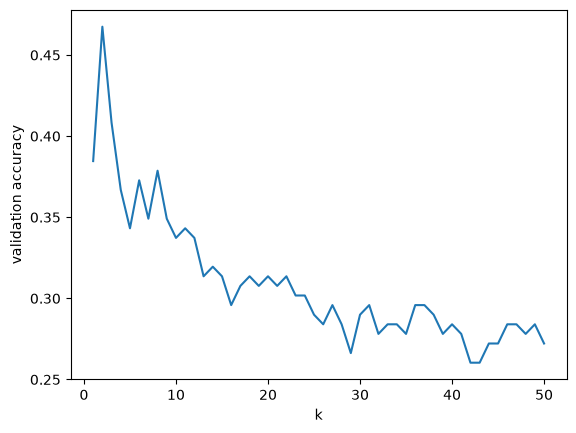

what i did? I Scanned k = 1 to 50, score each on the validation set, pick the k with highest validation accuracy
Q4
Predicted   1   2   3   4  5
Actual                      
1          27   0   5   2  2
2           0  31   2   1  1
3          10   2  10  10  1
4          15   6   3   9  0
5          15   0  10   5  2
accuracy: 0.467
accuracy is not great
So rows are actual, columns are  predicted, and diagonal is correct. Look for classes the model never predicts
Analysis: Based on the confusion matrix, performance is most accurate for mine types with high values on the diagonal. The model is less accurate for classes where there are high values off the diagonal, indicating which specific mine types it is confusing.
Q5
Because the model still makes a lot of mistakes, I would advise against using it as an autonomous decision maker. Instead, it should be configured to output probability distributions rather than hard labels. This allows operators to flag predictions with low confidence o

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler
import numpy as np

print('Q1')
df = pd.read_csv('data/land_mines.csv')
print("summary:\n", df[['voltage', 'height', 'soil']].describe())
print("\ndistribution:\n", df['mine_type'].value_counts())

print('Q2')
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X, y, test_size=0.50, stratify=y, random_state=65
)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_valid = scaler.transform(X_valid_raw)

print('Q3')
ks = np.arange(1, 51)
valid_acc = []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=int(k)).fit(X_train, y_train)
    valid_acc.append(accuracy_score(y_valid, m.predict(X_valid)))

k_star = int(ks[np.argmax(valid_acc)])
print(f"best k = {k_star}, validation accuracy = {max(valid_acc):.3f}")

plt.plot(ks, valid_acc); plt.xlabel("k"); plt.ylabel("validation accuracy"); plt.show()
print("what i did? I Scanned k = 1 to 50, score each on the validation set, pick the k with highest validation accuracy")

print('Q4')
model = KNeighborsClassifier(n_neighbors=k_star).fit(X_train, y_train)
y_hat = model.predict(X_valid)
confusion = pd.crosstab(y_valid, pd.Series(y_hat, index=y_valid.index), rownames=["Actual"], colnames=["Predicted"])
print(confusion)
print(f"accuracy: {accuracy_score(y_valid, y_hat):.3f}")
print("accuracy is not great")
print("So rows are actual, columns are  predicted, and diagonal is correct. Look for classes the model never predicts")
print("Analysis: Based on the confusion matrix, performance is most accurate for mine types with high values on the diagonal. The model is less accurate for classes where there are high values off the diagonal, indicating which specific mine types it is confusing.")

print('Q5')
print("Because the model still makes a lot of mistakes, I would advise against using it as an autonomous decision maker. Instead, it should be configured to output probability distributions rather than hard labels. This allows operators to flag predictions with low confidence or high uncertainty")

### *Reflection on AI assistance
In your own words without generative AI.

The main improvements were about making sure the details were correct. I fixed the way it talked about the confusion matrix by using the terms "True Positives" and explained that overfitting happens when a model learns the training data too well. I also added the missing analysis for Question 4 to show where the model did well and where it didn't. A big problem with the AI was that it first only looked at grammar. When I told it to ignore grammar those suggestions were not used so the original text stayed the same. Also the AI could only give an answer for Question 4 because it couldn't run the code or see the actual data. The final answer was checked by making sure only corrections related to machine learning were included. The main issue left is the answer, for Question 4. To fix that the code needs to be run to find out which classes the model gets mixed up with.